# IPL Model Comparison — All Models vs All Metrics
Run this AFTER running IPL_Project_Group5_Complete.ipynb (you need X.npy and y.npy)

In [1]:
!pip install scikit-learn imbalanced-learn seaborn --quiet
import time, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from collections import Counter
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
TEAM_NAMES = ['None','CSK','DC','GT','KKR','LSG','MI','PBKS','RR','RCB','SRH']
print('Libraries loaded!')

Libraries loaded!


## Load data and apply imbalance handling

In [10]:
X = np.load('X.npy')
y = np.load('y.npy')
print('Loaded X:', X.shape, '  y:', y.shape)

dist = Counter(y)
player_counts = [dist.get(t, 0) for t in range(1, 11) if dist.get(t, 0) > 0]
median_player = int(np.median(player_counts))

# Undersample class 0 and over-represented teams
under_targets = {0: median_player * 5}
for t in [3, 4]:
    if dist.get(t, 0) > median_player * 3:
        under_targets[t] = median_player * 3
X_u, y_u = RandomUnderSampler(sampling_strategy=under_targets, random_state=42).fit_resample(X, y)

# SMOTE for rare teams
dist2 = Counter(y_u)
target_n = max(dist2.get(t, 0) for t in range(1, 11))
smote_target = {t: target_n for t in range(1,11) if 0 < dist2.get(t,0) < target_n}
k = max(1, min(5, min((v for v in dist2.values() if v > 0), default=2) - 1))
X_s, y_s = SMOTE(sampling_strategy=smote_target, k_neighbors=k, random_state=42).fit_resample(X_u, y_u)

X_train, X_test, y_train, y_test = train_test_split(X_s, y_s, test_size=0.2, stratify=y_s, random_state=42)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Loaded X: (251776, 560)   y: (251776,)
Train: (46008, 560)  Test: (11502, 560)


## Defining the Models  

In [3]:
MODELS = {
    'SVM (RBF)': Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', probability=True))]),
    'SVM (Linear)': Pipeline([('s', StandardScaler()), ('c', SVC(kernel='linear', C=1, class_weight='balanced', probability=True))]),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42),
    'Gradient Boosting': Pipeline([('s', StandardScaler()), ('c', GradientBoostingClassifier(n_estimators=100, random_state=42))]),
    'KNN (k=7)': Pipeline([('s', StandardScaler()), ('c', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))]),
    'Logistic Regression': Pipeline([('s', StandardScaler()), ('c', LogisticRegression(max_iter=500, class_weight='balanced', C=1, solver='lbfgs', multi_class='multinomial', random_state=42, n_jobs=-1))]),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, class_weight='balanced', random_state=42),
    'AdaBoost': Pipeline([('s', StandardScaler()), ('c', AdaBoostClassifier(n_estimators=100, random_state=42))]),
    'Naive Bayes': Pipeline([('s', StandardScaler()), ('c', GaussianNB())]),
}
print('Defined', len(MODELS), 'models')

Defined 10 models


## Train and evaluate all models

In [ ]:
results, trained_models = [], {}

for name, model in MODELS.items():
    print(f'Training {name}...', end=' ', flush=True)
    t0 = time.time(); model.fit(X_train, y_train); train_time = time.time() - t0
    train_acc = model.score(X_train, y_train)
    test_acc  = model.score(X_test, y_test)
    y_pred    = model.predict(X_test)
    report    = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    t0 = time.time(); _ = model.predict(X_test[:100]); infer_ms = (time.time()-t0)/100*1000
    cv = cross_val_score(model, X_s, y_s, cv=3, n_jobs=-1)
    row = {'Model': name, 'Train Acc': round(train_acc,4), 'Test Acc': round(test_acc,4),
           'CV Mean': round(cv.mean(),4), 'CV Std': round(cv.std(),4),
           'Train Time (s)': round(train_time,2), 'Infer Time (ms)': round(infer_ms,3),
           'Overfit Gap': round(train_acc-test_acc,4)}
    for i, t in enumerate(TEAM_NAMES):
        row[f'F1_{t}'] = round(report.get(str(i), {}).get('f1-score', 0.0), 3)
    results.append(row); trained_models[name] = model
    print(f'Test={test_acc:.3f}  Time={train_time:.1f}s')
df = pd.DataFrame(results).sort_values('Test Acc', ascending=False).reset_index(drop=True)

df.to_csv('model_comparison_results.csv', index=False)
print('\nSaved model_comparison_results.csv')
df[['Model','Train Acc','Test Acc','CV Mean','CV Std','Train Time (s)','Overfit Gap']]

Training SVM (RBF)... Test=0.835  Time=8100.4s
Training SVM (Linear)... Test=0.749  Time=19678.9s
Training Random Forest... Test=0.821  Time=37.2s
Training Extra Trees... Test=0.791  Time=15.8s
Training Gradient Boosting... Test=0.811  Time=11477.8s
Training KNN (k=7)... Test=0.477  Time=0.7s
Training Logistic Regression... 

c:\Users\Aishwarea\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test=0.723  Time=13.6s
Training Decision Tree... Test=0.697  Time=49.5s
Training AdaBoost... Test=0.589  Time=323.8s
Training Naive Bayes... Test=0.611  Time=0.7s

Saved model_comparison_results.csv


,Model,Train Acc,Test Acc,CV Mean,CV Std,Train Time (s),Overfit Gap
0,SVM (RBF),0.9981,0.8354,0.8097,0.0405,8100.43,0.1627
1,Random Forest,1.0000,0.8207,0.8009,0.0326,37.17,0.1793
2,Gradient Boosting,0.8571,0.8107,0.7918,0.0282,11477.81,0.0464
3,Extra Trees,1.0000,0.7913,0.7818,0.0416,15.76,0.2087
4,SVM (Linear),0.8437,0.7494,0.7358,0.0321,19678.88,0.0942
5,Logistic Regression,0.7660,0.7233,0.7120,0.0296,13.64,0.0427
6,Decision Tree,0.9481,0.6968,0.6716,0.0299,49.49,0.2513
7,Naive Bayes,0.6179,0.6112,0.6004,0.0171,0.68,0.0067
8,AdaBoost,0.5947,0.5888,0.5752,0.0163,323.80,0.0059
9,KNN (k=7),0.5835,0.4765,0.4486,0.0245,0.71,0.1070


## Save best model

In [ ]:
best_name  = df.iloc[0]['Model']
best_model = trained_models[best_name]
joblib.dump(best_model, 'model_group45_11.pkl')
print(f'Best model: {best_name}')
print(f'Test Acc  : {df.iloc[0]["Test Acc"]}')
print(f'CV Mean   : {df.iloc[0]["CV Mean"]} ± {df.iloc[0]["CV Std"]}')
print('Saved model_group45_11.pkl')

Best model: SVM (RBF)
Test Acc  : 0.8564
CV Mean   : 0.8355 ± 0.0276
Saved model_group45_11.pkl


## Adding XGBOOST model which was trained in model_comparison_notebook_5_model.ipynb

In [27]:
df1 = pd.read_csv('model_comparison_results_5.csv')
df1[0:1]
df = pd.concat([df, df1[0:1]], ignore_index=True).sort_values('Test Acc', ascending=False).reset_index(drop=True)
df

,Model,Train Acc,Test Acc,CV Mean,CV Std,Train Time (s),Infer Time (ms),Overfit Gap,F1_None,F1_CSK,F1_DC,F1_GT,F1_KKR,F1_LSG,F1_MI,F1_PBKS,F1_RR,F1_RCB,F1_SRH
0,XGBoost,0.9982,0.8564,0.8355,0.0276,273.29,0.080,0.1418,0.867,0.919,0.868,0.837,0.915,0.882,0.847,0.745,0.921,0.675,0.899
1,SVM (RBF),0.9981,0.8354,0.8097,0.0405,8100.43,21.580,0.1627,0.853,0.907,0.914,0.816,0.894,0.894,0.832,0.662,0.907,0.592,0.849
2,Random Forest,1.0000,0.8207,0.8009,0.0326,37.17,0.409,0.1793,0.833,0.880,0.866,0.810,0.889,0.865,0.810,0.683,0.904,0.567,0.831
3,Gradient Boosting,0.8571,0.8107,0.7918,0.0282,11477.81,0.036,0.0464,0.844,0.873,0.781,0.784,0.895,0.800,0.804,0.687,0.875,0.590,0.863
4,Extra Trees,1.0000,0.7913,0.7818,0.0416,15.76,0.394,0.2087,0.791,0.869,0.891,0.799,0.860,0.878,0.776,0.623,0.905,0.432,0.786
5,SVM (Linear),0.8437,0.7494,0.7358,0.0321,19678.88,22.652,0.0942,0.778,0.819,0.786,0.689,0.864,0.767,0.724,0.597,0.843,0.525,0.766
6,Logistic Regression,0.7660,0.7233,0.7120,0.0296,13.64,0.036,0.0427,0.750,0.827,0.704,0.668,0.843,0.733,0.721,0.564,0.825,0.484,0.763
7,Decision Tree,0.9481,0.6968,0.6716,0.0299,49.49,0.002,0.2513,0.761,0.820,0.645,0.655,0.816,0.675,0.648,0.530,0.807,0.444,0.685
8,Naive Bayes,0.6179,0.6112,0.6004,0.0171,0.68,0.035,0.0067,0.723,0.804,0.507,0.461,0.807,0.579,0.556,0.402,0.747,0.296,0.564
9,AdaBoost,0.5947,0.5888,0.5752,0.0163,323.80,0.088,0.0059,0.718,0.728,0.459,0.592,0.776,0.516,0.495,0.463,0.745,0.207,0.248


## Accuracy comparison bar chart

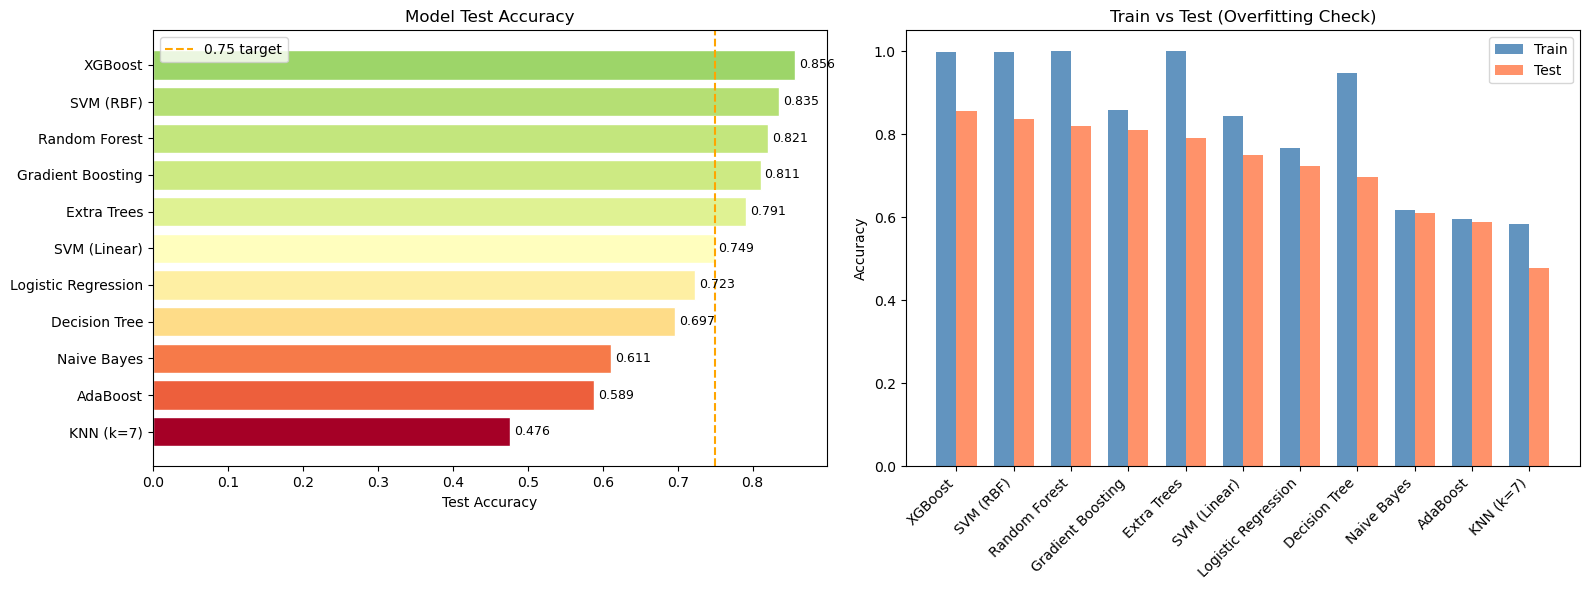

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sd = df.sort_values('Test Acc')
colors = plt.cm.RdYlGn(np.interp(sd['Test Acc'], [0.5, 1.0], [0.0, 1.0]))
axes[0].barh(sd['Model'], sd['Test Acc'], color=colors, edgecolor='white')
axes[0].axvline(0.75, color='orange', linestyle='--', linewidth=1.5, label='0.75 target')
axes[0].set_xlabel('Test Accuracy'); axes[0].set_title('Model Test Accuracy'); axes[0].legend()
for i,(acc,_) in enumerate(zip(sd['Test Acc'], sd['Model'])):
    axes[0].text(acc+0.005, i, f'{acc:.3f}', va='center', fontsize=9)
x = np.arange(len(df)); w = 0.35
axes[1].bar(x-w/2, df['Train Acc'], w, label='Train', color='steelblue', alpha=0.85)
axes[1].bar(x+w/2, df['Test Acc'],  w, label='Test',  color='coral',     alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(df['Model'], rotation=45, ha='right')
axes[1].set_ylabel('Accuracy'); axes[1].set_title('Train vs Test (Overfitting Check)'); axes[1].legend()
plt.tight_layout(); plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

## Per-team F1 heatmap

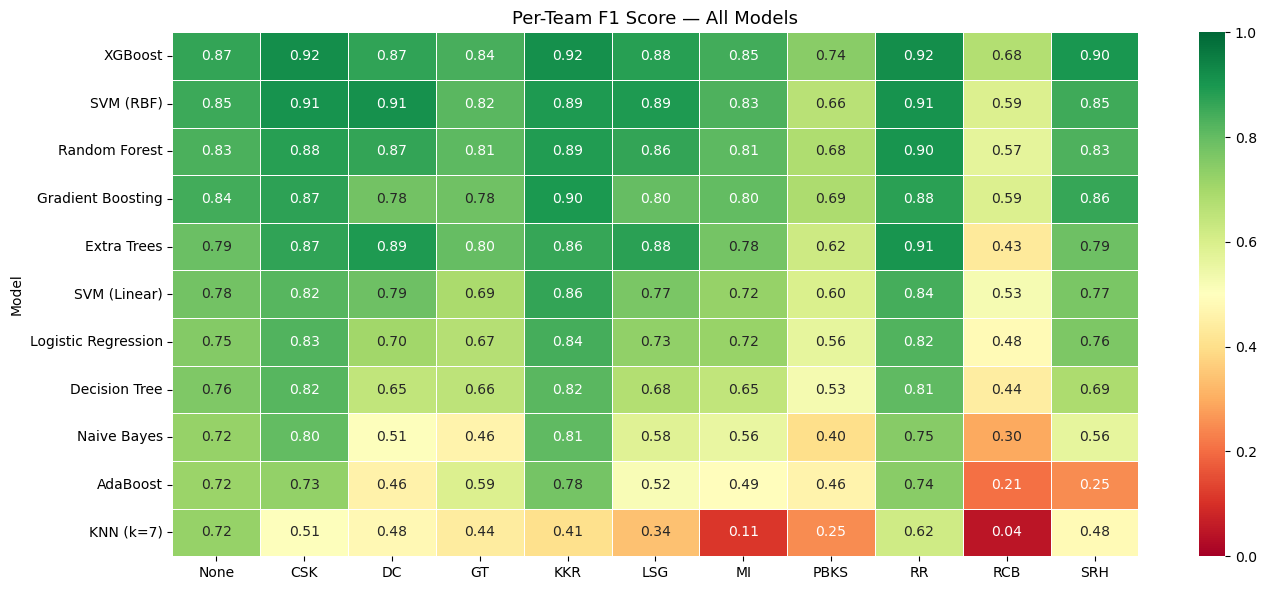

In [29]:
f1_cols = [f'F1_{t}' for t in TEAM_NAMES]
f1_df = df.set_index('Model')[f1_cols]; f1_df.columns = TEAM_NAMES
plt.figure(figsize=(14, 6))
sns.heatmap(f1_df, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5)
plt.title('Per-Team F1 Score — All Models', fontsize=13)
plt.tight_layout(); plt.savefig('f1_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

## Speed vs Accuracy scatter

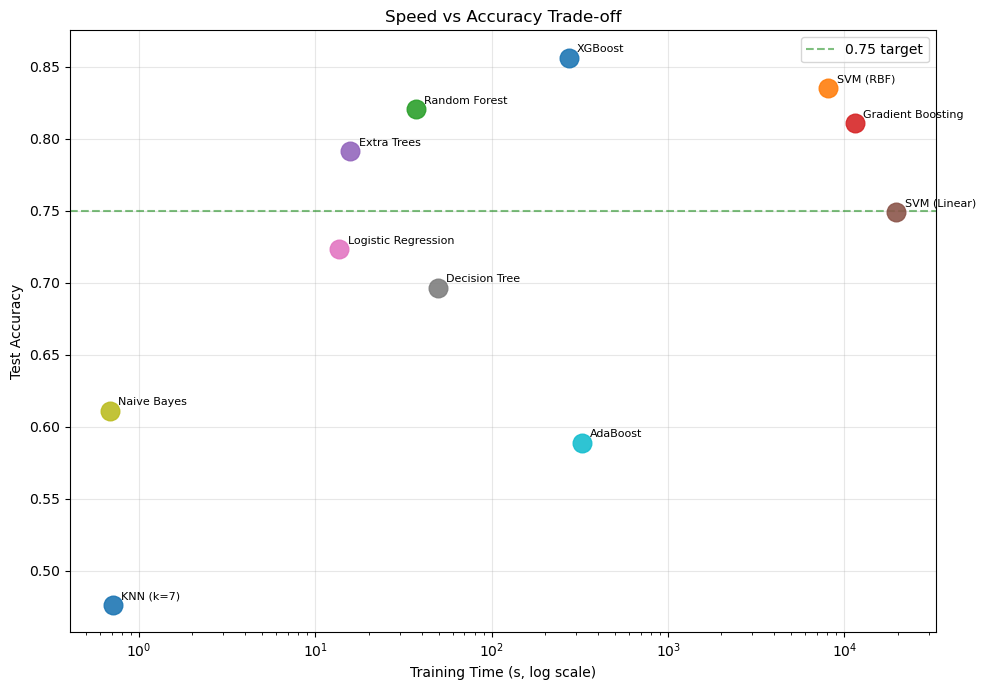

In [ ]:
plt.figure(figsize=(10, 7))
for _, row in df.iterrows():
    plt.scatter(row['Train Time (s)'], row['Test Acc'], s=180, zorder=5, alpha=0.9)
    plt.annotate(row['Model'], (row['Train Time (s)'], row['Test Acc']),
                 xytext=(6,4), textcoords='offset points', fontsize=8)
plt.xscale('log'); plt.xlabel('Training Time (s, log scale)'); plt.ylabel('Test Accuracy')
plt.title('Speed vs Accuracy Trade-off')
plt.axhline(0.75, color='green', linestyle='--', alpha=0.5, label='0.75 target'); plt.legend()
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('speed_vs_accuracy.png', dpi=150, bbox_inches='tight'); plt.show()

## Confusion matrix for best model

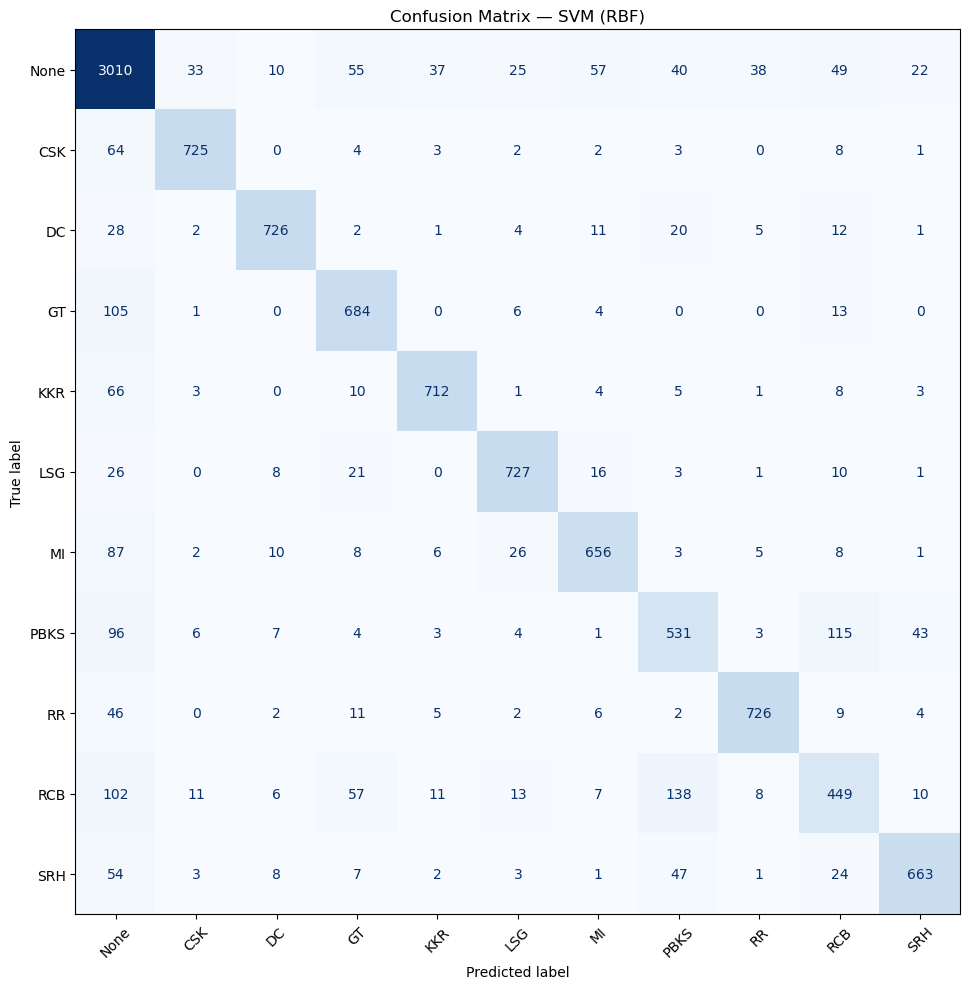

In [31]:
y_pred = trained_models[best_name].predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm, display_labels=TEAM_NAMES).plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}'); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()